<a href="https://colab.research.google.com/github/sjkim0520/Mechanical_Project/blob/main/main_mrr_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 2 목표:

**압력(P)와 회전속도(N) 변화에 따른 MRR 응답 면적(Response Surface)을 시각화 합니다.**

**2-1: 필요한 라이브러리 불러오기**

시각화와 수치 계산을 위한 핵심 패키지들을 임포트합니다. 3D 그래프 생성을 위해 mpl_toolkits,mplot3d 모듈도 함께 불러옵니다.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D #3D 시각화용

2-2: 상수 및 단위 변환 식 정의하기

Preston 법칙($MRR = k_p \cdot P \cdot V$)을 적용하려면 물리 단위 표준화($\text{psi} \rightarrow \text{Pa}$, $\text{RPM} \rightarrow \text{rad/s}$)가 필요합니다.

In [11]:
#상수 선언
PSI_TO_PA= 6894.76 #1psi당 pa값
Kp=1.5e-13 #Preston 꼐수 (M^2/N)
PLATEN_RADIUS=0.3 #Platen의 가상 반지름 (m)

#단위 변환 함수 작성
def rpm_to_velocity(rpm, radius):
  omega=rpm*2*(np.pi)/60
  return omega*radius #선속도(m/s)

**2-3: 2D 격자(Meshgrid) 생성 및 MRR 계산하기**

압력 $1 \sim 5 \text{ psi}$와 회전 속도 $30 \sim 120 \text{ rpm}$ 범위를 생성하고 np.meshgrid로 2차원 교차 행렬을 만듭니다.

In [13]:
# 데이터 격자 생성 및 MRR 계산
# 1. 1차원 배열 생성 (각 50개 포인트)
p_array = np.linspace(1, 5, 50)     # Pressure: 1 ~ 5 psi
rpm_array = np.linspace(30, 120, 50) # Speed: 30 ~ 120 rpm

# 2. 2D Meshgrid 생성
P_grid, RPM_grid = np.meshgrid(p_array, rpm_array)

# 3. 단위 변환 적용
P_pa = P_grid * PSI_TO_PA
V_ms = rpm_to_velocity(RPM_grid, PLATEN_RADIUS)

# 4. Preston 법칙 적용 (MRR 계산)
MRR_m_s = Kp * P_pa * V_ms
MRR_nm_min = MRR_m_s * 6e+10  # m/s -> nm/min 변환 multiplier 채우기

**2-4: 2D Contour Map (등고선도) 그리기**

공정 마진(Process Window)을 한눈에 파악하기 위한 2D 히트맵을 생성합니다.

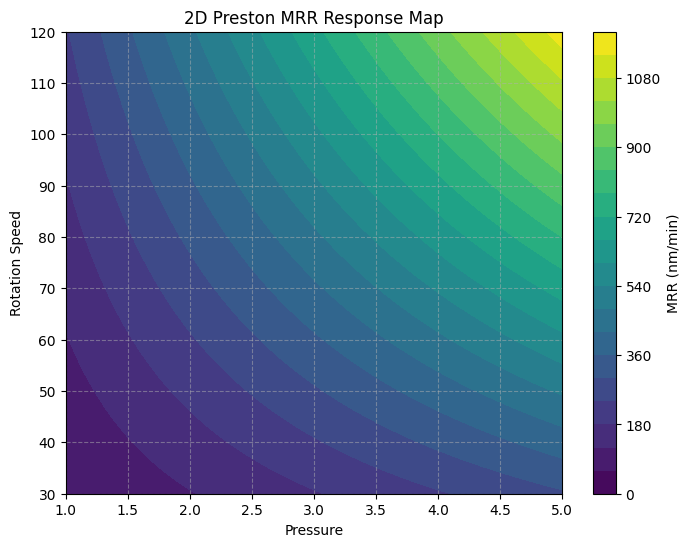

In [14]:
# 2D Contour Plot 시각화
plt.figure(figsize=(8, 6))

# plt.contourf를 이용해 채워진 등고선 그리기
contour = plt.contourf(P_grid, RPM_grid, MRR_nm_min, levels=20, cmap='viridis')

# 컬러바 및 축 라벨 추가
plt.colorbar(contour, label='MRR (nm/min)')
plt.title('2D Preston MRR Response Map')
plt.xlabel('Pressure')  # X축 라벨 작성 (Pressure)
plt.ylabel('Rotation Speed')  # Y축 라벨 작성 (Rotation Speed)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**2-5: 3D Surface Plot 그리기**

P와 RPM 상호작용에 따른 반응 표면 (Response Surface)을 3차원 입체로 시작화 합니다.

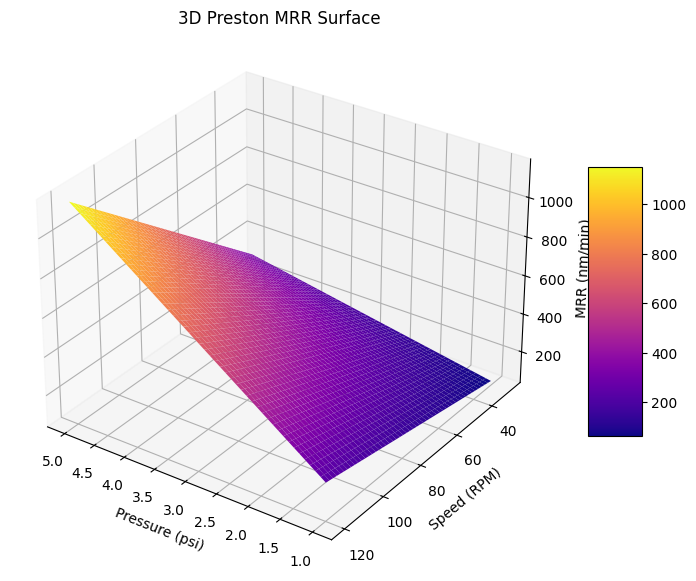

In [15]:
# 3D Surface Plot 시각화
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 3D 표면 그리기 (plot_surface)
surf = ax.plot_surface(P_grid, RPM_grid, MRR_nm_min, cmap='plasma', edgecolor='none')

# 축 라벨 및 컬러바 설정
ax.set_title('3D Preston MRR Surface')
ax.set_xlabel('Pressure (psi)')
ax.set_ylabel('Speed (RPM)')
ax.set_zlabel('MRR (nm/min)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# 시야각 조절 (elevation, azimuth)
ax.view_init(elev=30, azim=125)

plt.show()

# Step 3 목표

**: 웨이퍼 반경 반향 상대속도 프로파일 및 WIWNU(불균일도) 정량 산출**

**3-1: 필요한 라이브러리 및 공정 기본 상수 정의**

반경 방향 측정 포인트 및 수치 계산을 위한 패키지와 상수를 선언합니다.

In [1]:
#라이브러리 및 상수 정의
import numpy as np
import matplotlib.pyplot as plt

PSI_TO_PA = 6894.76           # 1 psi = 6894.76 Pa
RPM_TO_RAD_S = 2 * np.pi / 60 # RPM -> rad/s 변환
KP = 1.5e-13                  # Preston 계수 (m^2/N)
R_OFFSET = 0.3                # Platen 중심 - 캐리어 중심 오프셋 거리 (m)

**3-2: 반경별 상대속도 V(r) 및 MRR(r) 산출 함수 작성**

웨이퍼 중심(r=0)부터 Edge(r=150mm)까지 17개 측정 포인트에서의 상대속도와 재료 제거율을 산출합니다.

In [3]:
# 반경별 MRR 프로파일 산출 함수
def calculate_mrr_profile(omega_p_rpm, omega_c_rpm, pressure_psi=3.0, r_max_mm=150, n_points=17):
    # 각속도 변환 (rad/s)
    w_p = omega_p_rpm * RPM_TO_RAD_S
    w_c = omega_c_rpm * RPM_TO_RAD_S
    P_pa = pressure_psi * PSI_TO_PA

    # 0 ~ 150mm 반경 측정 포인트 배열 생성 (m 단위 변환)
    r_arr = np.linspace(0, r_max_mm / 1000.0, n_points)

    # 위치별 상대속도 V(r) 계산
    V_r = np.sqrt((w_p * R_OFFSET)**2 + ((w_p - w_c) * r_arr)**2)  # w_p와 w_c의 차이 적용

    # Preston 법칙 적용 (m/s -> nm/min 변환)
    MRR_r = KP * P_pa * V_r * 1e9 * 60

    return r_arr * 1000.0, MRR_r  # (mm 단위 반경, nm/min 단위 MRR)

**3-3: WIWNU(%) 정량 산출 함수 작성**

웨이퍼 내 측정 포인트들의 평균과 표준편차를 이용해 불균일도를 백분율로 산출합니다.

In [4]:
#WIWNU 계산 함수 작성
def calculate_wiwnu(mrr_array):
    mean_mrr = np.mean(mrr_array)  # MRR 평균값
    std_mrr = np.std(mrr_array)    # MRR 표준편차

    # WIWNU 공식 적용 (표준편차 / 평균 * 100)
    wiwnu = (std_mrr / mean_mrr) * 100      # 빈칸 채우기
    return wiwnu, mean_mrr, std_mrr

**3-4: 회전 조건 비교 시뮬레이션 실행 (비동기 VS 동기)**

Platen과 캐리어의 회전 속도가 다를 때 (Case A)와 같을 때 (Case B)의 불균일도를 비교, 계산합니다.

In [5]:
# 시뮬레이션 실행 및 결과 출력
# Case A: 비동기 회전 조건 (Platen: 60 RPM, Carrier: 40 RPM)
r_a, mrr_a = calculate_mrr_profile(omega_p_rpm=60, omega_c_rpm=40)
wiwnu_a, mean_a, std_a = calculate_wiwnu(mrr_a)

# Case B: 동기 회전 조건 (Platen: 60 RPM, Carrier: 60 RPM)
r_b, mrr_b = calculate_mrr_profile(omega_p_rpm=60, omega_c_rpm=60)
wiwnu_b, mean_b, std_b = calculate_wiwnu(mrr_b)

# 결과 수치 출력
print(f"=== CMP Kinematics WIWNU Evaluation ===")
print(f"[Case A - Async (60/40 RPM)] Mean MRR: {mean_a:.2f} nm/min | WIWNU: {wiwnu_a:.2f}%")
print(f"[Case B - Sync  (60/60 RPM)] Mean MRR: {mean_b:.2f} nm/min | WIWNU: {wiwnu_b:.2f}%")

=== CMP Kinematics WIWNU Evaluation ===
[Case A - Async (60/40 RPM)] Mean MRR: 352.57 nm/min | WIWNU: 0.44%
[Case B - Sync  (60/60 RPM)] Mean MRR: 350.90 nm/min | WIWNU: 0.00%


**3-5: 웨이퍼 반경 방향 MRR Profile 시각화**

중심(r=0)에서 edge(r=150mm)로 갈수록 제거율이 어떻게 변하는지 비교 그래프를 생성합니다.

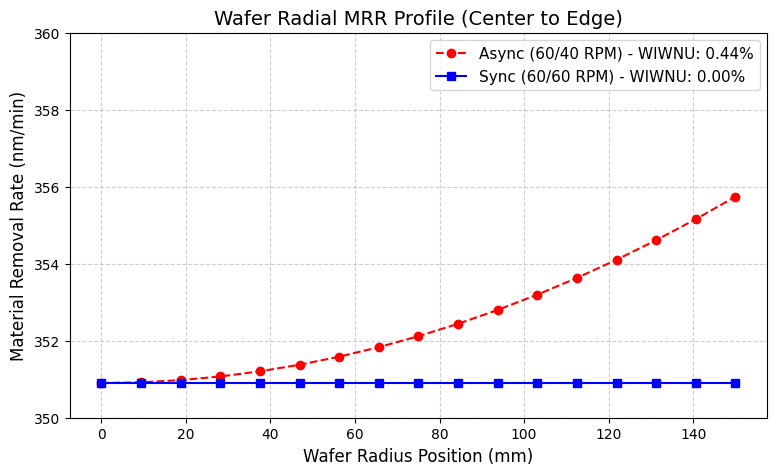

In [8]:
# Radial MRR Profile 그래프 시각화
plt.figure(figsize=(9, 5))

plt.plot(r_a, mrr_a, 'r--o', label=f'Async (60/40 RPM) - WIWNU: {wiwnu_a:.2f}%')
plt.plot(r_b, mrr_b, 'b-s', label=f'Sync (60/60 RPM) - WIWNU: {wiwnu_b:.2f}%')

plt.title('Wafer Radial MRR Profile (Center to Edge)', fontsize=14)
plt.xlabel('Wafer Radius Position (mm)', fontsize=12)
plt.ylabel('Material Removal Rate (nm/min)', fontsize=12)
plt.ylim(350, 360)  # 경향성 확인용 Y축 범위 설정
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.show()